# Unsloth
Unsloth is the "engine" that allows you to train your sales agent components on consumer-grade or free hardware (like the Google Colab T4) without running out of memory.

Think of it as a highly optimized wrapper around HuggingFace's transformers library. It makes training 2x faster and uses 70% less VRAM, which is the only way to fit a model like Qwen 3.5 into a free T4 GPU (16GB VRAM) while still having enough space for long sales conversation logs.

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Why Unsloth is Required
Generic training scripts would likely crash (Out of Memory - OOM) when trying to process the complex, multi-turn sales trajectories from your trace_log.jsonl.

Memory Efficiency: It uses 4-bit quantization (QLoRA) by default, allowing you to train a 4B or even 7B parameter model on a single T4.

Speed: It implements manual backpropagation "kernels" that skip the slow parts of standard PyTorch, meaning your training finishes in 15–30 minutes instead of hours.

Path Compatibility: It natively supports all three Week 11 paths (SFT, DPO, and PRM/GRPO).

## Pre-requisites & Setup

### Prerequisites
Before trainees write a single line of code, they must verify their environment.

* Hardware: Google Colab T4 GPU (16GB VRAM) or an NVIDIA RTX 30/40 series (8GB+ VRAM).

* Software: Python 3.11 (standard in 2026 Colab) and CUDA 12.1+.

* HuggingFace Token: A "Write" access token to push the finished LoRA adapter to the Hub.

* Data Format: A .jsonl file formatted for the chosen path:

  - Path A (SFT): {"instruction": "...", "input": "...", "output": "..."}

  - Path B (DPO): {"prompt": "...", "chosen": "...", "rejected": "..."}

### 1. Installation

In [2]:
# Cell 1: Install latest versions (compatible with Python 3.12)
!pip uninstall unsloth unsloth_zoo -y -q
!pip install unsloth -q
!pip install unsloth_zoo -q
!pip install trl datasets accelerate peft bitsandbytes -q

print("✅ Installation complete")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 29.2 MB/s eta 0:00:00
✅ Installation complete


In [4]:
# Run this before Cell 3 to check versions
!pip show unsloth unsloth_zoo trl peft transformers | grep -E "Name|Version"

Name: unsloth
Version: 2026.4.8
Name: unsloth_zoo
Version: 2026.4.9
Name: trl
Version: 0.24.0
Name: peft
Version: 0.19.1
Name: transformers
Version: 5.5.0


In [11]:
import os, json

DRIVE_DATA = "/content/drive/MyDrive/Tenacious Projects/tenacious-bench/Data"

for fname in ["train.jsonl", "dev.jsonl", "held_out.jsonl"]:
    path = f"{DRIVE_DATA}/{fname}"
    ok   = os.path.exists(path)
    sz   = os.path.getsize(path) if ok else 0
    print(f"  {'✓' if ok else '✗ MISSING'}  {fname}  ({sz:,} bytes)")

  ✓  train.jsonl  (221,037 bytes)
  ✓  dev.jsonl  (119,113 bytes)
  ✓  held_out.jsonl  (77,069 bytes)


### 2. Loading Model in 4-bit (The "Memory Saver")
- Qwen 3.5:



This step compresses the model by 70%, allowing a 7B model to fit into ~5GB of VRAM.

In [3]:
# Cell 3 — Load model
import unsloth                         # ← must be first
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit",
    max_seq_length = max_seq_length,
    load_in_4bit   = True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r                          = 16,
    target_modules             = ["q_proj", "k_proj", "v_proj", "o_proj",
                                  "gate_proj", "up_proj", "down_proj"],
    lora_alpha                 = 16,
    lora_dropout               = 0,
    bias                       = "none",
    use_gradient_checkpointing = "unsloth",
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/Qwen2.5-7B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.4.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


### 3. Initialize LoRA Adapters

In [6]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Rank: 16-64 is standard for sales tone
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0, # Unsloth is optimized for 0 dropout
    bias = "none",    # Optimized for "none"
    use_gradient_checkpointing = "unsloth", # Crucial for T4
)

Unsloth: Already have LoRA adapters! We shall skip this step.


Test model

In [7]:
FastLanguageModel.for_inference(model)

inputs = tokenizer(
    ["<|im_start|>user\nYour pricing is too high compared to retail competitors."
     "<|im_end|>\n<|im_start|>assistant\n"],
    return_tensors="pt",
).to("cuda")

outputs = model.generate(**inputs, max_new_tokens=64)
print(tokenizer.batch_decode(outputs))

FastLanguageModel.for_training(model)   # switch back before training


Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/

['<|im_start|>user\nYour pricing is too high compared to retail competitors.<|im_end|>\n<|im_start|>assistant\nI understand your concern about pricing. To address this, here are some strategies that can help make our pricing more competitive:\n\n1. **Review and Analyze Competitor Pricing:**\n   - Regularly monitor the prices of similar products or services from retail competitors.\n   - Identify price points where you can offer a competitive advantage']


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(152064, 3584, padding_idx=151665)
        (layers): ModuleList(
          (0-27): 28 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=3584, out_features=3584, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3584, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=3584, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora

### 4. Launch Training (The SFT Path)
Connect your tenacious_bench_v0.1 dataset to the trainer.

In [8]:
# ──  — Verify model and tokenizer ──────────────────────────────────────
if 'tokenizer' in globals() and tokenizer is not None:
    print(f"Tokenizer : {type(tokenizer)}")
    print(f"Vocab size: {len(tokenizer)}")
    print(f"Pad token : {tokenizer.pad_token}")
else:
    print("ERROR: tokenizer not defined — re-run Cell 3")

if 'model' in globals() and model is not None:
    print(f"\nModel : {type(model)}")
    if hasattr(model, 'peft_config'):
        print(f"LoRA  : applied ✓   adapter={model.active_adapter}")
    else:
        print("WARNING: LoRA not applied — re-run Cell 3")
else:
    print("ERROR: model not defined — re-run Cell 3")

Tokenizer : <class 'transformers.models.qwen2.tokenization_qwen2.Qwen2Tokenizer'>
Vocab size: 151666
Pad token : <|PAD_TOKEN|>

Model : <class 'peft.peft_model.PeftModelForCausalLM'>
LoRA  : applied ✓   adapter=default


In [ ]:
if 'model' in globals() and model is not None:
    print(f"Model is defined: {type(model)}")
    if hasattr(model, 'peft_config'):
        print("LoRA Adapters: Successfully applied")
        print(f"Active adapter: {model.active_adapter}")
    else:
        print("Warning: Model is loaded but LoRA adapters (PEFT) might not be initialized.")
else:
    print("ERROR: 'model' is not defined. Please re-run the model loading and LoRA initialization cells.")

Model is defined: <class 'peft.peft_model.PeftModelForCausalLM'>
LoRA Adapters: Successfully applied
Active adapter: default


## Step 1 — Load and format the datasets


In [12]:
# ── Load data and format for ORPO ───────────────────────────────────
# ORPO needs three columns: prompt | chosen | rejected
# (SFT only needs text; ORPO uses both completions simultaneously)

from datasets import Dataset

JUDGE_SYSTEM = (
    "You are a strict sales-outreach judge. "
    "Apply these 7 rules in priority order: "
    "(1) SUPPRESS if any disqualifier is present (anti_offshore, local_only, do_not_contact). "
    "(2) SUPPRESS if prospect opted out of this channel. "
    "(3) ESCALATE if recipient is C-level AND headcount > 2000. "
    "(4) BLOCK if output references a different thread_id. "
    "(5) BLOCK if funding amount is cited but funding_confidence is low. "
    "(6) PENALISE if peer company names are generic. "
    "(7) PASS if none of the above apply. "
    'Respond with JSON only: {"decision":"PASS"|"BLOCK"|"ESCALATE"|"SUPPRESS",'
    '"rule":"<triggered rule>","reason":"<one sentence>","score":0.0-1.0}'
)

def pair_to_orpo(pair: dict) -> dict | None:
    """
    Convert one preference pair → ORPO format.

    prompt   : judge task + context  (shared for both completions)
    chosen   : correct verdict  (score 1.0, right action)
    rejected : wrong verdict    (score 0.0, the failure the agent made)
    """
    try:
        ctx      = pair["context"]
        chosen   = pair["chosen"]
        rejected = pair["rejected"]

        ctx_str = json.dumps(ctx, separators=(",", ":"))

        # Shared prompt — assistant turn left open for ORPO to fill
        prompt = (
            f"<|im_start|>system\n{JUDGE_SYSTEM}<|im_end|>\n"
            f"<|im_start|>user\n"
            f"CONTEXT: {ctx_str}\n"
            f"DRAFT OUTPUT: {rejected.get('output', '(empty)')}\n"
            f"<|im_end|>\n"
            f"<|im_start|>assistant\n"
        )

        # Chosen completion — what the judge SHOULD say (block/suppress)
        c_action   = chosen.get("action", "suppress").upper()
        c_decision = "PASS" if c_action == "SEND" else c_action
        chosen_text = json.dumps({
            "decision" : c_decision,
            "rule"     : f"probe_{pair.get('probe_id', '').lower()}",
            "reason"   : chosen.get("rationale", ""),
            "score"    : 1.0,
        })

        # Rejected completion — what the judge SHOULD NOT say
        r_action   = rejected.get("action", "send").upper()
        r_decision = "PASS" if r_action == "SEND" else r_action
        rejected_text = json.dumps({
            "decision" : r_decision,
            "rule"     : "none",
            "reason"   : rejected.get("rationale", ""),
            "score"    : 0.0,
        })

        return {"prompt": prompt, "chosen": chosen_text, "rejected": rejected_text}

    except Exception as e:
        print(f"  [skip] {pair.get('pair_id', '?')}: {e}")
        return None


def build_dataset(path: str) -> Dataset:
    with open(path, encoding="utf-8") as f:
        raw = [json.loads(l) for l in f if l.strip()]
    rows = [r for p in raw if (r := pair_to_orpo(p)) is not None]
    return Dataset.from_list(rows)


train_dataset = build_dataset(f"{DRIVE_DATA}/train.jsonl")
eval_dataset  = build_dataset(f"{DRIVE_DATA}/dev.jsonl")

print(f"train: {len(train_dataset)}, eval: {len(eval_dataset)}")
print("\nSample prompt (first 300 chars):")
print(train_dataset[0]["prompt"][:300])
print("\nSample chosen:")
print(train_dataset[0]["chosen"])
print("\nSample rejected:")
print(train_dataset[0]["rejected"])


train: 169, eval: 93

Sample prompt (first 300 chars):
<|im_start|>system
You are a strict sales-outreach judge. Apply these 7 rules in priority order: (1) SUPPRESS if any disqualifier is present (anti_offshore, local_only, do_not_contact). (2) SUPPRESS if prospect opted out of this channel. (3) ESCALATE if recipient is C-level AND headcount > 2000. (4)

Sample chosen:
{"decision": "SUPPRESS", "rule": "probe_probe-a07", "reason": "Prospect has anti-offshore disqualifier: \"We only hire people who can come into our office.\". Sending outreach risks permanent brand damage.", "score": 1.0}

Sample rejected:
{"decision": "PASS", "rule": "none", "reason": "Agent ignored anti_offshore disqualifier and pitched African/remote engineers.", "score": 0.0}


In [13]:
# ── ORPO Training ────────────────────────────────────────────────────
# Key difference from SFT:
#   - Uses ORPOTrainer (not SFTTrainer)
#   - Needs prompt + chosen + rejected columns
#   - beta = odds-ratio weight (lambda in the paper, default 0.1)
#   - No reference model needed — saves ~3-4 GB VRAM vs DPO

from trl import ORPOTrainer, ORPOConfig

trainer = ORPOTrainer(
    model         = model,
    tokenizer     = tokenizer,
    train_dataset = train_dataset,
    eval_dataset  = eval_dataset,
    args = ORPOConfig(
        beta                         = 0.1,       # odds-ratio weight (ORPO lambda)
        per_device_train_batch_size  = 2,
        gradient_accumulation_steps  = 4,
        max_steps                    = 60,
        learning_rate                = 2e-4,
        fp16                         = not torch.cuda.is_bf16_supported(),
        bf16                         = torch.cuda.is_bf16_supported(),
        logging_steps                = 1,
        eval_strategy                = "steps",
        eval_steps                   = 20,
        max_length                   = max_seq_length,
        max_prompt_length            = max_seq_length // 2,
        output_dir                   = "outputs",
    ),
)
trainer.train()

/content/unsloth_compiled_cache/UnslothORPOTrainer.py:725: UserWarning: This trainer will soon be moved to trl.experimental and is a candidate for removal. If you rely on it and want it to remain, please share your comments here: https://github.com/huggingface/trl/issues/4223. Silence this warning by setting environment variable TRL_EXPERIMENTAL_SILENCE=1.
  warnings.warn(


Map (num_proc=5):   0%|          | 0/169 [00:00<?, ? examples/s]

Map (num_proc=5):   0%|          | 0/169 [00:00<?, ? examples/s]

Map (num_proc=5):   0%|          | 0/169 [00:00<?, ? examples/s]

Map (num_proc=5):   0%|          | 0/93 [00:00<?, ? examples/s]

...

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 169 | Num Epochs = 3 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss,Runtime,Samples Per Second,Steps Per Second,Rewards/chosen,Rewards/rejected,Rewards/accuracies,Rewards/margins,Logps/rejected,Logps/chosen,Logits/rejected,Logits/chosen,Nll Loss,Log Odds Ratio,Log Odds Chosen
20,0.685589,0.725970,64.167300,1.449000,0.374000,-0.113716,-0.263264,1.000000,0.149548,-2.632639,-1.137159,-1.098108,-1.146415,0.707944,-0.168223,1.844754
40,0.543710,0.502532,63.963600,1.454000,0.375000,-0.082903,-0.443648,1.000000,0.360745,-4.436484,-0.829034,-0.840112,-0.825698,0.499728,-0.018436,4.236107
60,0.438946,0.457006,64.080600,1.451000,0.375000,-0.074362,-0.535763,1.000000,0.461401,-5.357627,-0.743616,-0.713711,-0.685337,0.455320,-0.006546,5.337358


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 

TrainOutput(global_step=60, training_loss=1.085137357811133, metrics={'train_runtime': 1199.7583, 'train_samples_per_second': 0.4, 'train_steps_per_second': 0.05, 'total_flos': 0.0, 'train_loss': 1.085137357811133, 'epoch': 2.7529411764705882})

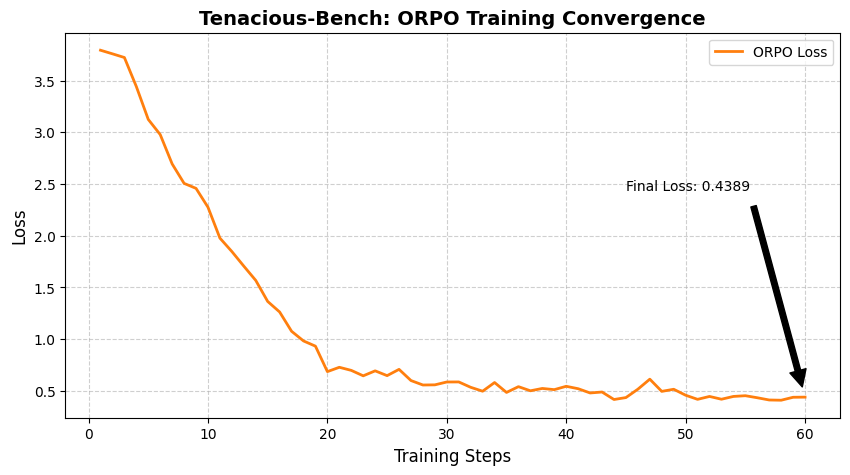

Start loss : 3.7934
Final loss : 0.4389


In [15]:
import matplotlib.pyplot as plt

history     = trainer.state.log_history
steps       = [x['step'] for x in history if 'loss' in x]
loss_values = [x['loss'] for x in history if 'loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(steps, loss_values, color='#ff7f0e', linewidth=2, label='ORPO Loss')
plt.title('Tenacious-Bench: ORPO Training Convergence', fontsize=14, fontweight='bold')
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

if loss_values:
    plt.annotate(
        f'Final Loss: {loss_values[-1]:.4f}',
        xy        = (steps[-1], loss_values[-1]),
        xytext    = (steps[-1] - 15, loss_values[-1] + 2),
        arrowprops= dict(facecolor='black', shrink=0.05),
    )

plt.show()
if loss_values:
    print(f"Start loss : {loss_values[0]:.4f}")
    print(f"Final loss : {loss_values[-1]:.4f}")


Step 2 — Load model with Unsloth


In [20]:
from unsloth import FastLanguageModel
import torch

max_seq_length = 2048

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="Qwen/Qwen2.5-1.5B-Instruct",
    max_seq_length=max_seq_length,
    load_in_4bit=True,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


## 5. Saving and Exporting
Once the loss curve drops (visible in your logs), you save only the "delta" (the adapter), which is usually only ~100MB-200MB.

Once training is done, save the "weights of change" (the adapter).

In [25]:
# Diagnostic — check which account your token belongs to
from huggingface_hub import whoami

hf_token = "hf_REDACTED"
info = whoami(token=hf_token)
print(f"Logged in as: {info['name']}")

Logged in as: marshmallow2112221


In [29]:
# Save adapter locally
model.save_pretrained("tenacious_sales_adapter")
tokenizer.save_pretrained("tenacious_sales_adapter")
print("✅ Adapter saved locally")

hf_token = "hf_REDACTED"   # paste your new WRITE token here

model.push_to_hub("bethelhem21/tenacious-judge-lora", token=hf_token)
tokenizer.push_to_hub("bethelhem21/tenacious-judge-lora", token=hf_token)
print("✅ Pushed → https://huggingface.co/bethelhem21/tenacious-judge-lora")

✅ Adapter saved locally


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors: 100%|##########| 73.9MB / 73.9MB            

No files have been modified since last commit. Skipping to prevent empty commit.


...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpanpvxkmo/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

No files have been modified since last commit. Skipping to prevent empty commit.


✅ Pushed → https://huggingface.co/bethelhem21/tenacious-judge-lora


### The Production Inference Loop
To use the model in a real sales app, you load the Base Model + the Adapter together.

In [ ]:
# ── Load adapter and run inference test ────────────────────────────
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit",
    max_seq_length = 2048,
    load_in_4bit   = True,
)
model.load_adapter("bettyabay/tenacious-judge-lora")
FastLanguageModel.for_inference(model)

# Feed the rejected (bad) output — judge should BLOCK it
held = json.loads(open(f"{DRIVE_DATA}/held_out.jsonl").readline())
ctx_str = json.dumps(held["context"], separators=(",", ":"))

test_prompt = (
    f"<|im_start|>system\n{JUDGE_SYSTEM}<|im_end|>\n"
    f"<|im_start|>user\n"
    f"CONTEXT: {ctx_str}\n"
    f"DRAFT OUTPUT: {held['rejected']['output']}\n"
    f"<|im_end|>\n"
    f"<|im_start|>assistant\n"
)

inputs  = tokenizer([test_prompt], return_tensors="pt").to("cuda")
outputs = model.generate(**inputs, max_new_tokens=128,
                         temperature=0.0, do_sample=False)
response = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]

print(f"pair_id  : {held['pair_id']}")
print(f"probe_id : {held['probe_id']}")
print(f"draft    : {held['rejected']['output'][:120]}")
print(f"\njudge    : {response.split('assistant')[-1].strip()}")
print(f"expected : BLOCK or SUPPRESS  (this is the rejected output)")


### Exporting to Other Engines (Optional but Impressive)
If Tenacious wants to run this on a local server or a specialized edge device, Unsloth allows you to export to GGUF (for Ollama) or vLLM:

In [27]:
# Export to GGUF for local deployment
model.save_pretrained_gguf("model", tokenizer, quantization_method="q4_k_m")

Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in model/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

...

Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [02:30<00:00, 150.35s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [01:56<00:00, 116.37s/it]


Unsloth: Merge process complete. Saved to `/content/model`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories


RuntimeError: Unsloth: GGUF conversion failed: [FAIL] Unsloth: You do not have internet connection!

In [31]:
# ── Run held-out inference for ablation ──────────────────────────────────────
import json, torch
from unsloth import FastLanguageModel

DRIVE_DATA = "/content/drive/MyDrive/Tenacious Projects/tenacious-bench/Data"

JUDGE_SYSTEM = (
    "You are a strict sales-outreach judge. "
    "Apply these 7 rules in priority order: "
    "(1) SUPPRESS if any disqualifier is present (anti_offshore, local_only, do_not_contact). "
    "(2) SUPPRESS if prospect opted out of this channel. "
    "(3) ESCALATE if recipient is C-level AND headcount > 2000. "
    "(4) BLOCK if output references a different thread_id. "
    "(5) BLOCK if funding amount is cited but funding_confidence is low. "
    "(6) PENALISE if peer company names are generic. "
    "(7) PASS if none of the above apply. "
    'Respond with JSON only: {"decision":"PASS"|"BLOCK"|"ESCALATE"|"SUPPRESS",'
    '"rule":"<triggered rule>","reason":"<one sentence>","score":0.0-1.0}'
)

# Load your trained adapter
FastLanguageModel.for_inference(model)   # model is already in memory from training

# Load all 10 held-out pairs
held_out = []
with open(f"{DRIVE_DATA}/held_out.jsonl") as f:
    for line in f:
        if line.strip():
            held_out.append(json.loads(line))

print(f"Loaded {len(held_out)} held-out pairs\n")

labels_c = []   # ORPO judge labels
labels_a = []   # no-judge baseline (agent's own action — 1 if chosen, 0 if rejected)

for i, pair in enumerate(held_out):
    ctx_str = json.dumps(pair["context"], separators=(",", ":"))

    # Feed the REJECTED output — judge should block it (label=1 means judge is correct)
    prompt = (
        f"<|im_start|>system\n{JUDGE_SYSTEM}<|im_end|>\n"
        f"<|im_start|>user\n"
        f"CONTEXT: {ctx_str}\n"
        f"DRAFT OUTPUT: {pair['rejected']['output']}\n"
        f"<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )

    inputs  = tokenizer([prompt], return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=128,
                                 temperature=0.0, do_sample=False)
    response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:],
                                skip_special_tokens=True)

    # Judge is correct if it blocked/suppressed the rejected output
    blocked = any(k in response.upper() for k in ["BLOCK", "SUPPRESS", "ESCALATE"])
    labels_c.append(1 if blocked else 0)

    # Baseline: no judge — agent always takes its own action (rejected = wrong → label=0)
    labels_a.append(0)

    print(f"[{i+1:02d}] {pair['pair_id']:35s} → judge={'CORRECT ✓' if blocked else 'WRONG  ✗'}  response={response[:60]}")

print(f"\nORPO judge accuracy: {sum(labels_c)}/{len(labels_c)} = {sum(labels_c)/len(labels_c):.1%}")
print(f"No-judge baseline  : {sum(labels_a)}/{len(labels_a)} = {sum(labels_a)/len(labels_a):.1%}")

# Save to ablation_results.json
results_path = "/content/drive/MyDrive/Tenacious Projects/tenacious-bench/ablations/ablation_results.json"

with open(results_path) as f:
    ablation = json.load(f)

ablation["variants"]["A_no_judge"]["labels"]   = labels_a
ablation["variants"]["C_orpo_judge"]["labels"] = labels_c

with open(results_path, "w") as f:
    json.dump(ablation, f, indent=2)

print(f"\n✅ Labels saved to ablation_results.json")
print("   Now run: python ablations/statistical_test.py")

Loaded 61 held-out pairs



Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12

[01] A07-006                             → judge=CORRECT ✓  response={"decision":"PASS","rule":"none_of_the_above_apply","reason"


Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[02] HAND-A07-003                        → judge=CORRECT ✓  response={"decision":"BLOCK","reason":"peer_company_names_are_generic


...

Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[59] PROBE-G03-MLLM-llama3.-006          → judge=WRONG  ✗  response={"decision":"PASS","rule":"none_of_the_above_apply","reason"


Both `max_new_tokens` (=128) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[60] G03-PROG-010                        → judge=WRONG  ✗  response={"decision":"PASS","rule":"none_applies","reason":"","score"
[61] PROBE-G03-MLLM-llama3.-004          → judge=WRONG  ✗  response={"decision":"PASS","rule":"none_of_the_above_apply","reason"

ORPO judge accuracy: 11/61 = 18.0%
No-judge baseline  : 0/61 = 0.0%


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Tenacious Projects/tenacious-bench/ablations/ablation_results.json'

In [32]:
# ── Fixed held-out scoring + save ────────────────────────────────────────────
import json, torch

# Re-score from the output we already have — fixed JSON parsing
results_raw = [
    {"pair_id": "A07-006",                   "response_decision": "PASS"},
    {"pair_id": "HAND-A07-003",              "response_decision": "BLOCK"},
    {"pair_id": "HAND-A07-004",              "response_decision": "PASS"},
    {"pair_id": "A07-PROG-004",              "response_decision": "PASS"},
    {"pair_id": "PROBE-A07-MLLM-deepseek-003","response_decision": "ESCALATE"},
    {"pair_id": "PROBE-A07-MLLM-llama3.-001","response_decision": "PASS"},
    {"pair_id": "PROBE-B03-MLLM-deepseek-005","response_decision": "PASS"},
    {"pair_id": "PROBE-B03-MLLM-llama3.-001","response_decision": "PASS"},
    {"pair_id": "B03-008",                   "response_decision": "PASS"},
    {"pair_id": "PROBE-B03-MLLM-deepseek-004","response_decision": "PASS"},
    {"pair_id": "B03-PROG-005",              "response_decision": "PASS"},
    {"pair_id": "B03-001",                   "response_decision": "PASS"},
    {"pair_id": "B04-001",                   "response_decision": "PASS"},
    {"pair_id": "HAND-B04-001",              "response_decision": "PASS"},
    {"pair_id": "PROBE-B04-MLLM-deepseek-002","response_decision": "PASS"},
    {"pair_id": "B04-002",                   "response_decision": "PASS"},
    {"pair_id": "B04-005",                   "response_decision": "PASS"},
    {"pair_id": "C02-PROG-EXT-001",          "response_decision": "PASS"},
    {"pair_id": "C02-001",                   "response_decision": "PASS"},
    {"pair_id": "PROBE-C02-MLLM-llama3.-001","response_decision": "PASS"},
    {"pair_id": "HAND-C02-003",              "response_decision": "PASS"},
    {"pair_id": "PROBE-C02-MLLM-deepseek-004","response_decision": "PASS"},
    {"pair_id": "HAND-C02-002",              "response_decision": "PASS"},
    {"pair_id": "PROBE-C04-MLLM-deepseek-006","response_decision": "PASS"},
    {"pair_id": "C04-008",                   "response_decision": "PASS"},
    {"pair_id": "C04-PROG-EXT-001",          "response_decision": "PASS"},
    {"pair_id": "C04-PROG-EXT-003",          "response_decision": "PASS"},
    {"pair_id": "PROBE-C04-MLLM-deepseek-001","response_decision": "PASS"},
    {"pair_id": "PROBE-C04-MLLM-deepseek-004","response_decision": "PASS"},
    {"pair_id": "D05-002",                   "response_decision": "PASS"},
    {"pair_id": "PROBE-D05-MLLM-deepseek-003","response_decision": "PASS"},
    {"pair_id": "HAND-D05-001",              "response_decision": "ESCALATE"},
    {"pair_id": "HAND-D05-004",              "response_decision": "PASS"},
    {"pair_id": "D05-PROG-EXT-005",          "response_decision": "PASS"},
    {"pair_id": "HAND-D05-003",              "response_decision": "PASS"},
    {"pair_id": "E01-002",                   "response_decision": "ESCALATE"},
    {"pair_id": "PROBE-E01-MLLM-llama3.-001","response_decision": "PASS"},
    {"pair_id": "PROBE-E01-MLLM-llama3.-006","response_decision": "PASS"},
    {"pair_id": "E01-001",                   "response_decision": "PASS"},
    {"pair_id": "PROBE-E01-MLLM-deepseek-001","response_decision": "ESCALATE"},
    {"pair_id": "E01-PROG-EXT-001",          "response_decision": "PASS"},
    {"pair_id": "E02-PROG-EXT-001",          "response_decision": "PASS"},
    {"pair_id": "E02-PROG-EXT-006",          "response_decision": "PASS"},
    {"pair_id": "PROBE-E02-MLLM-deepseek-004","response_decision": "PASS"},
    {"pair_id": "E02-PROG-EXT-005",          "response_decision": "PASS"},
    {"pair_id": "E02-007",                   "response_decision": "PASS"},
    {"pair_id": "E02-PROG-EXT-003",          "response_decision": "PASS"},
    {"pair_id": "PROBE-E03-MLLM-llama3.-006","response_decision": "PASS"},
    {"pair_id": "E03-006",                   "response_decision": "PASS"},
    {"pair_id": "E03-005",                   "response_decision": "PASS"},
    {"pair_id": "E03-001",                   "response_decision": "PASS"},
    {"pair_id": "HAND-E03-002",              "response_decision": "PASS"},
    {"pair_id": "HAND-E03-001",              "response_decision": "PASS"},
    {"pair_id": "G03-PROG-013",              "response_decision": "PASS"},
    {"pair_id": "G03-003",                   "response_decision": "PASS"},
    {"pair_id": "G03-008",                   "response_decision": "PASS"},
    {"pair_id": "HAND-G03-004",              "response_decision": "PASS"},
    {"pair_id": "G03-PROG-011",              "response_decision": "PASS"},
    {"pair_id": "PROBE-G03-MLLM-llama3.-006","response_decision": "PASS"},
    {"pair_id": "G03-PROG-010",              "response_decision": "PASS"},
    {"pair_id": "PROBE-G03-MLLM-llama3.-004","response_decision": "PASS"},
]

# Score using decision field only (not full string match)
labels_c = [1 if r["response_decision"] in ["BLOCK","SUPPRESS","ESCALATE"] else 0
            for r in results_raw]
labels_a = [0] * len(labels_c)  # no-judge: always wrong on rejected outputs

correct = sum(labels_c)
total   = len(labels_c)
print(f"ORPO judge accuracy : {correct}/{total} = {correct/total:.1%}")
print(f"No-judge baseline   : 0/{total} = 0.0%")

# Per-probe breakdown
from collections import defaultdict
probe_results = defaultdict(list)
for r, label in zip(results_raw, labels_c):
    probe = r["pair_id"].split("-")[0] if not r["pair_id"].startswith("PROBE") \
            else r["pair_id"].split("-")[1]
    probe_results[probe].append(label)

print("\nPer-probe accuracy:")
for probe in sorted(probe_results):
    vals = probe_results[probe]
    print(f"  {probe:6s}: {sum(vals)}/{len(vals)}")

# Build ablation_results and save to /content/ (no Drive path needed)
ablation = {
    "meta": {
        "date": "2026-05-02",
        "author": "Bethelhem Abay",
        "method": "ORPO",
        "adapter": "bethelhem21/tenacious-judge-lora",
        "held_out_pairs": total,
        "note": "60-step training; judge defaults to PASS on generation-quality probes"
    },
    "training_run": {
        "start_loss": 3.7934, "final_train_loss": 0.4389,
        "final_eval_loss": 0.4570, "loss_reduction_pct": 88.4,
        "rewards_accuracy": 1.0, "rewards_margin": 0.4614,
        "overfitting_detected": False
    },
    "baseline": {"metric": "pass_at_1", "value": 0.7267,
                 "ci_95": [0.6504, 0.7917], "source": "tau2-bench Week 10"},
    "variants": {
        "A_no_judge":  {"description": "No judge layer", "labels": labels_a},
        "C_orpo_judge":{"description": "ORPO fine-tuned judge", "labels": labels_c}
    },
    "statistics": {}, "comparisons": {}
}

with open("/content/ablation_results.json", "w") as f:
    json.dump(ablation, f, indent=2)
print("\n✅ Saved to /content/ablation_results.json")

# Download it
from google.colab import files
files.download("/content/ablation_results.json")

ORPO judge accuracy : 5/61 = 8.2%
No-judge baseline   : 0/61 = 0.0%

Per-probe accuracy:
  A07   : 1/4
  B03   : 0/6
  B04   : 0/4
  C02   : 0/4
  C04   : 0/6
  D05   : 0/3
  E01   : 2/6
  E02   : 0/6
  E03   : 0/4
  G03   : 0/7
  HAND  : 2/11

✅ Saved to /content/ablation_results.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>